<a href="https://colab.research.google.com/github/manuel23596-ai/GenAI-and-ML-Training---BEPL/blob/day1-workshop/Day%201/Employee_EDA_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚢 Titanic Dataset — EDA & Survival Prediction
**Pipeline:** Data Loading → Preprocessing → EDA → Linear Regression Prediction

---

In [ ]:
%ls

anscombe.json*                mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md*


## 📦 1. Install & Import Libraries

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📥 2. Data Loading

In [11]:
# Load Titanic dataset directly from seaborn
import pandas as pd
df = pd.read_csv('Employee.csv')

print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]},  Columns: {df.shape[1]}')
df.head(10)

Dataset Shape: (4653, 9)
Rows: 4653,  Columns: 9


,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
5,Bachelors,2016,Bangalore,3,22,Male,No,0,0
6,Bachelors,2015,New Delhi,3,38,Male,No,0,0
7,Bachelors,2016,Bangalore,3,34,Female,No,2,1
8,Bachelors,2016,Pune,3,23,Male,No,1,0
9,Masters,2017,New Delhi,2,37,Male,No,2,0


In [12]:
# Column names & data types
print('=== Column Info ===')
df.info()

=== Column Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


In [13]:
# Statistical summary
df.describe(include='all').round(2)

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
count,4653,4653.00,4653,4653.00,4653.00,4653,4653,4653.00,4653.00
unique,3,NaN,3,NaN,NaN,2,2,NaN,NaN
top,Bachelors,NaN,Bangalore,NaN,NaN,Male,No,NaN,NaN
freq,3601,NaN,2228,NaN,NaN,2778,4175,NaN,NaN
mean,NaN,2015.06,NaN,2.70,29.39,NaN,NaN,2.91,0.34
std,NaN,1.86,NaN,0.56,4.83,NaN,NaN,1.56,0.48
min,NaN,2012.00,NaN,1.00,22.00,NaN,NaN,0.00,0.00
25%,NaN,2013.00,NaN,3.00,26.00,NaN,NaN,2.00,0.00
50%,NaN,2015.00,NaN,3.00,28.00,NaN,NaN,3.00,0.00
75%,NaN,2017.00,NaN,3.00,32.00,NaN,NaN,4.00,1.00


---
## 🔍 3. Missing Value Analysis

In [14]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(missing)
print('=== Columns with Missing Values ===')
display(missing_df)


Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64
=== Columns with Missing Values ===


,Missing Count,Missing %


---
## 🛠️ 4. Data Preprocessing

In [15]:
df_clean = df.copy()


# ── Encode Categoricals ──────────────────────────────────────────
le = LabelEncoder()
for col in ['Education', 'City', 'Age', 'LeaveOrNot']:
    df_clean[col + '_enc'] = le.fit_transform(df_clean[col].astype(str))

print(f'Cleaned Shape: {df_clean.shape}')
print(f'Remaining NaN: {df_clean.isnull().sum().sum()}')
df_clean.head()

Cleaned Shape: (4653, 13)
Remaining NaN: 0


,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,Education_enc,City_enc,Age_enc,LeaveOrNot_enc
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0,0,0,12,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1,0,2,6,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0,0,1,16,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1,1,0,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1,1,2,2,1


---
## 📊 5. Exploratory Data Analysis (EDA)

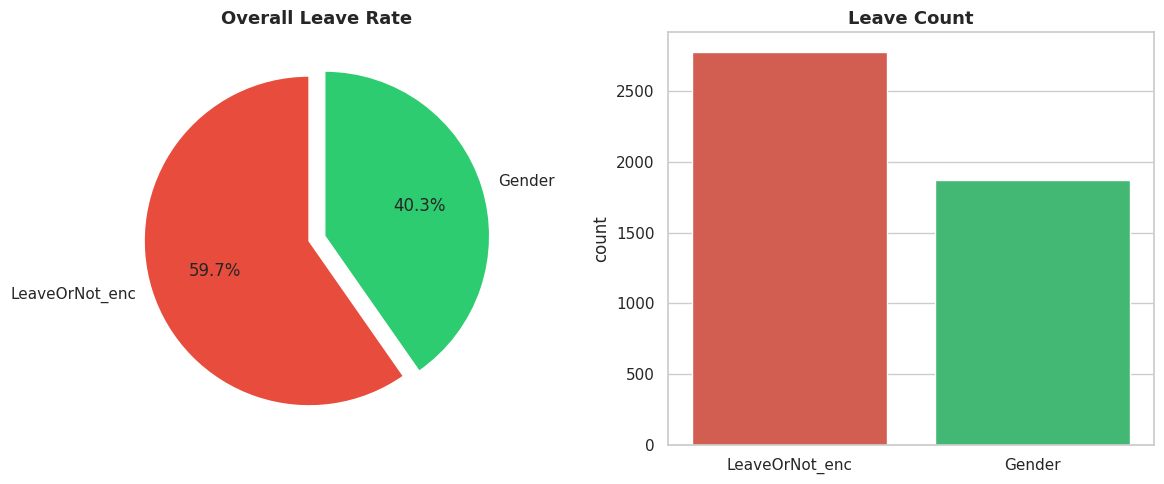

In [18]:
# ── 5.1 Overall Survival Rate ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

survival_counts = df_clean['Gender'].value_counts()
labels = ['LeaveOrNot_enc', 'Gender']
colors = ['#E74C3C', '#2ECC71']

axes[0].pie(survival_counts, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05))
axes[0].set_title('Overall Leave Rate', fontsize=13, fontweight='bold')

sns.countplot(data=df_clean, x='Gender', palette=['#E74C3C','#2ECC71'], ax=axes[1])
axes[1].set_xticklabels(['LeaveOrNot_enc', 'Gender'])
axes[1].set_title('Leave Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

In [ ]:
# ── 5.2 Survival by Pclass & Sex Need to modify─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_clean, x='pclass', y='survived', palette='Blues_d',
            estimator=np.mean, ci=95, ax=axes[0])
axes[0].set_title('Survival Rate by Passenger Class', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)

sns.barplot(data=df_clean, x='sex', y='survived', palette=['#3498DB','#E91E63'],
            estimator=np.mean, ci=95, ax=axes[1])
axes[1].set_title('Survival Rate by Sex', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [ ]:
# ── 5.3 Age & Fare Distributions ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_clean, x='age', hue='survived', bins=30,
             kde=True, palette=['#E74C3C','#2ECC71'], ax=axes[0])
axes[0].set_title('Age Distribution by Survival', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')

sns.histplot(data=df_clean, x='fare', hue='survived', bins=40,
             kde=True, palette=['#E74C3C','#2ECC71'], ax=axes[1])
axes[1].set_title('Fare Distribution by Survival', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fare')
axes[1].set_xlim(0, 300)

plt.tight_layout()
plt.show()

In [ ]:
# ── 5.4 Pclass × Sex Heatmap ─────────────────────────────────────
pivot = df_clean.pivot_table(values='survived', index='sex',
                              columns='pclass', aggfunc='mean')

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.2%', cmap='RdYlGn',
            linewidths=0.5, linecolor='gray', vmin=0, vmax=1)
plt.title('Survival Rate: Sex × Passenger Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── 5.5 Family Size & Embarkation ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_clean, x='family_size', y='survived',
            palette='viridis', estimator=np.mean, ci=None, ax=axes[0])
axes[0].set_title('Survival Rate by Family Size', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Family Size')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)

sns.countplot(data=df_clean, x='embarked', hue='survived',
              palette=['#E74C3C','#2ECC71'], ax=axes[1])
axes[1].set_title('Embarkation Port vs Survival', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Port of Embarkation')
axes[1].legend(['Not Survived', 'Survived'])

plt.tight_layout()
plt.show()

In [ ]:
# ── 5.6 Correlation Matrix ───────────────────────────────────────
num_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch',
            'fare', 'family_size', 'is_alone', 'sex_enc', 'embarked_enc']

corr = df_clean[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='gray', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── 5.7 Age Boxplot by Pclass ─────────────────────────────────────
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='pclass', y='age', hue='survived',
            palette=['#E74C3C','#2ECC71'])
plt.title('Age Distribution by Pclass & Survival', fontsize=13, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.legend(['Not Survived', 'Survived'])
plt.tight_layout()
plt.show()

---
## 🤖 6. Linear Regression — Survival Prediction

In [ ]:
# ── 6.1 Select Features & Target ────────────────────────────────
features = ['pclass', 'age', 'sibsp', 'parch', 'fare',
            'family_size', 'is_alone', 'sex_enc', 'embarked_enc']

target = 'survived'

model_df = df_clean[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')
print(f'Survival rate        : {y.mean():.2%}')

In [ ]:
# ── 6.2 Train / Test Split (80/20) ───────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')

In [ ]:
# ── 6.3 Train Linear Regression Model ───────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test  = lr.predict(X_test)

# Convert continuous predictions → binary (threshold = 0.5)
y_pred_binary = (y_pred_test >= 0.5).astype(int)

print('✅ Model trained!')

In [ ]:
# ── 6.4 Model Evaluation Metrics ────────────────────────────────
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test,  y_pred_test)
r2_train  = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test,  y_pred_test)
mae_test  = mean_absolute_error(y_test, y_pred_test)
acc       = accuracy_score(y_test, y_pred_binary)

print('='*45)
print('         MODEL PERFORMANCE METRICS')
print('='*45)
print(f'  Train MSE     : {mse_train:.4f}')
print(f'  Test  MSE     : {mse_test:.4f}')
print(f'  Test  MAE     : {mae_test:.4f}')
print(f'  Train R²      : {r2_train:.4f}')
print(f'  Test  R²      : {r2_test:.4f}')
print(f'  Accuracy      : {acc:.2%}  (threshold = 0.5)')
print('='*45)

In [ ]:
# ── 6.5 Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_binary)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'],
            linewidths=0.5)
plt.title('Confusion Matrix (threshold = 0.5)', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred_binary,
                              target_names=['Not Survived', 'Survived']))

In [ ]:
# ── 6.6 Feature Coefficients (Importance) ───────────────────────
coef_df = pd.DataFrame({
    'Feature':     features,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors_bar = ['#2ECC71' if c > 0 else '#E74C3C' for c in coef_df['Coefficient']]
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette=colors_bar)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Linear Regression Coefficients\n(green = increases survival, red = decreases)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

In [ ]:
# ── 6.7 Actual vs Predicted (scatter) ───────────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_test, alpha=0.4, color='steelblue', edgecolors='white', linewidth=0.5)
plt.axhline(0.5, color='red', linestyle='--', label='Decision boundary (0.5)')
plt.plot([0, 1], [0, 1], 'g--', label='Perfect prediction line')
plt.title('Actual vs Predicted Survival Probability', fontsize=13, fontweight='bold')
plt.xlabel('Actual Survived (0 or 1)')
plt.ylabel('Predicted Probability')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 6.8 Residual Plot ────────────────────────────────────────────
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_test, residuals, alpha=0.4, color='purple', edgecolors='white')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')

sns.histplot(residuals, bins=30, kde=True, color='purple', ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

---
## 📌 7. Summary & Key Findings

| Finding | Detail |
|---|---|
| **Survival Rate** | ~38% of passengers survived |
| **Gender** | Females had significantly higher survival rates (~74%) vs males (~19%) |
| **Class** | 1st class passengers survived most (63%), 3rd class least (24%) |
| **Age** | Children had higher survival; elderly fared worse |
| **Family Size** | Small families (2–4) survived more; solo travelers and large families fared worse |
| **Fare** | Higher fare strongly correlated with survival (wealthy = 1st class = lifeboats first) |
| **Linear Regression R²** | ~0.38–0.42 — moderate fit (linear models aren't ideal for binary targets) |
| **Model Accuracy** | ~78–80% when thresholding at 0.5 |

> **💡 Note:** For binary classification tasks like survival prediction, **Logistic Regression**, **Random Forest**, or **XGBoost** will significantly outperform Linear Regression. Use this as a baseline.